In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
import shutil


In [3]:
filepath = 'Fourier/13' #Path for archives
script_dir = os.path.dirname('rnn_fourier.ipynb')
results_dir = os.path.join(script_dir, filepath + '/')

if not os.path.isdir(results_dir):
    os.makedirs(results_dir)

In [4]:
# Define Hyper Parameters

hidden_size = 128
num_classes = 7
num_epochs = 50
batch_size = 8
learning_rate = 0.0001
num_layers = 2
input_size = 128
sequence_length = 4 
     

bin_size = 750
take_max = True
normalize = True

# Device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
# Load Data
xy = np.load('./coin_data.npy')

In [6]:
def compute_fft_features(data, sample_rate=204000):
    
    """
    Computes FFT features from time-series data.
    
    Parameters:
        data (numpy array): Input dataset where first column is the label.
        sample_rate (int): Sampling rate of the audio.
    Returns:
        labels (numpy array): Extracted labels.
        fft_magnitudes (numpy array): FFT magnitude values.
        freqs (numpy array): Corresponding frequency values.
    """

    labels = data[:, 0]  # Extract labels
    signals = data[:, 1:]  # Extract time-series signals
    N = signals.shape[1]  # Number of time points00

    try:
        fft_magnitudes = np.load('./fft_magnitudes.npy')
    except:
        fft_features = np.fft.rfft(signals, axis=1) # Compute FFT
        fft_magnitudes = np.abs(fft_features)  # Compute magnitude
        np.save('fft_magnitudes', fft_magnitudes)


    freqs = np.fft.rfftfreq(N, d=1/sample_rate) # Compute actual freq. val.

    return labels, fft_magnitudes, freqs

In [7]:
def bin_fft_frequencies(fft_magnitudes, freqs, bin_size, take_max, normalize):
    """
    Bins the FFT magnitudes by either averaging or taking the max over a range of frequency bins.
    
    Parameters:
        fft_magnitudes (numpy array): FFT magnitude values (batch_size, num_freq_bins).
        freqs (numpy array): Corresponding frequency values (num_freq_bins,).
        bin_size (int): Number of frequency bins to group.
        take_max (bool): If True, takes the maximum value in each bin, otherwise averages.
    
    Returns:
        binned_magnitudes (numpy array): Magnitudes after binning (batch_size, num_bins).
        binned_freqs (numpy array): New binned frequency values (num_bins,).
    """
    # Determine the number of bins (group frequencies into bins of bin_size)
    num_freq_bins = fft_magnitudes.shape[1]
    num_bins = num_freq_bins // bin_size

    binned_magnitudes = []
    binned_freqs = []

    for i in range(num_bins):
        start_idx = i * bin_size
        end_idx = min((i + 1) * bin_size, num_freq_bins)

        if take_max:
            # Get the max amplitude across all samples for the current frequency bin
            bin_magnitude = np.max(fft_magnitudes[:, start_idx:end_idx], axis=1)
            
            # Find the frequency with the max amplitude (max across samples in that range)
            max_idx = np.argmax(np.max(fft_magnitudes[:, start_idx:end_idx], axis=0)) + start_idx  # Global max in the bin
            bin_freq = freqs[max_idx]
        else:
            # Average the values in the range and take the mean frequency
            bin_magnitude = np.mean(fft_magnitudes[:, start_idx:end_idx], axis=1)
            bin_freq = np.mean(freqs[start_idx:end_idx])

        binned_magnitudes.append(bin_magnitude)
        binned_freqs.append(bin_freq)

    # Convert lists to arrays
    binned_magnitudes = np.array(binned_magnitudes).T  # Shape: (batch_size, num_bins)
    binned_freqs = np.array(binned_freqs)

    if normalize:
        # Normalize magnitudes per sample (audio)
        min_magnitude = np.min(binned_magnitudes, axis=1, keepdims=True)
        max_magnitude = np.max(binned_magnitudes, axis=1, keepdims=True)
        normalized_magnitudes = (binned_magnitudes - min_magnitude) / (max_magnitude - min_magnitude)

    return normalized_magnitudes, binned_magnitudes, binned_freqs

In [8]:
y, fft_magnitudes, freqs = compute_fft_features(xy)
X, binned_magnitudes, binned_freqs = bin_fft_frequencies(fft_magnitudes, freqs, bin_size, take_max, normalize)

In [9]:
mapping = {
       0:"1 Cent",
       1:"2 Cent",
       2:"5 Cent",
       3:"20 Cent",
       4:"50 Cent",
       5:"1 Euro",
       6:"2 Euro"
}

(384513,)
(1094, 384513)


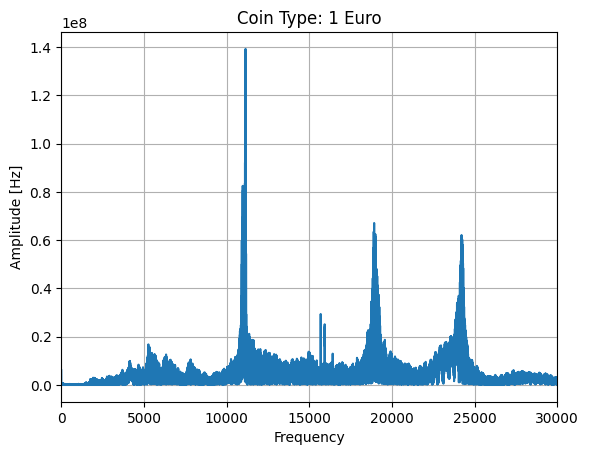

(512,)
(1094, 512)


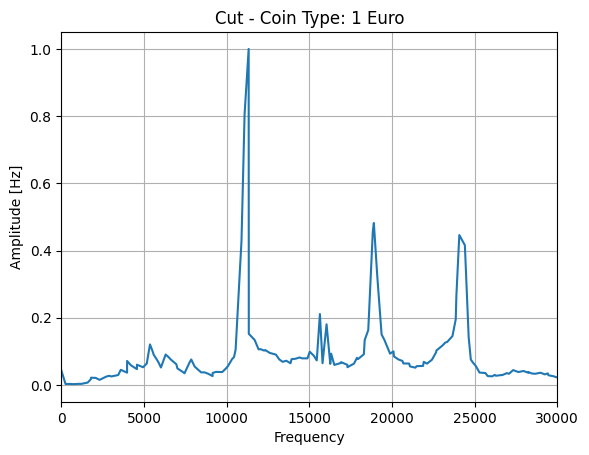

In [10]:
print(freqs.shape)
print(fft_magnitudes.shape)
plt.figure()
plt.plot(freqs, fft_magnitudes[0])
plt.xlabel("Frequency")
plt.ylabel("Amplitude [Hz]")
plt.title(f'Coin Type: {mapping[y[0]]}')
plt.xlim(0, 30000)
plt.grid()
plt.show()

print(binned_freqs.shape)
print(X.shape)
plt.figure()
plt.plot(binned_freqs, X[0])
plt.xlabel("Frequency")
plt.ylabel("Amplitude [Hz]")
plt.title(f'Cut - Coin Type: {mapping[y[0]]}')
plt.xlim(0, 30000)
plt.grid()
plt.show()

In [11]:
print(f'XY Shape: {xy.shape}')
print(f'X Shape: {X.shape}')

coin_1 = 0
coin_2 = 0
coin_5 = 0
coin_20 = 0
coin_50 = 0
coin_100 = 0
coin_200 = 0
for i in range(xy.shape[0]):
    if xy[i,0] == 0:
        coin_1 += 1
    elif xy[i,0] == 1:
        coin_2 += 1
    elif xy[i,0] == 2:
        coin_5 += 1
    elif xy[i,0] == 3:
        coin_20 += 1
    elif xy[i,0] == 4:
        coin_50 += 1
    elif xy[i,0] == 5:
        coin_100 += 1
    elif xy[i,0] == 6:
        coin_200 += 1
print(f'coin 1: {coin_1}')
print(f'coin 2: {coin_2}')
print(f'coin 5: {coin_5}')
print(f'coin 20: {coin_20}')
print(f'coin 50: {coin_50}')
print(f'coin 100: {coin_100}')
print(f'coin 200: {coin_200}')

XY Shape: (1094, 769025)
X Shape: (1094, 512)
coin 1: 151
coin 2: 170
coin 5: 130
coin 20: 137
coin 50: 130
coin 100: 180
coin 200: 196


In [12]:
# Set random seed for reproducibility
torch.manual_seed(7)  # Set the seed for generating random numbers in PyTorch
np.random.seed(7)     # Set the seed for generating random numbers in NumPy

Example Input Data: [7.95416161e-02 6.73971791e-03 4.71235299e-03 4.12576227e-03
 4.19094646e-03 3.68155027e-03 3.56817059e-03 3.10760224e-03
 3.26223159e-03 3.66520858e-03 3.62927304e-03 3.74566484e-03
 6.13112049e-03 6.59209350e-03 8.63119960e-03 1.12979272e-02
 9.83922835e-03 1.29233710e-02 1.40872365e-02 2.12728381e-02
 2.36752219e-02 2.28689406e-02 2.77628098e-02 2.55453102e-02
 3.05049140e-02 3.43779773e-02 2.86180153e-02 2.71633677e-02
 3.10533959e-02 2.84435004e-02 2.62029562e-02 2.67564822e-02
 2.13424712e-02 2.42231693e-02 2.42668856e-02 2.90116649e-02
 2.15024631e-02 1.75254606e-02 1.72287729e-02 2.01996844e-02
 6.51802421e-02 1.11985750e-01 3.85693610e-02 3.22049372e-02
 3.27434987e-02 3.13653722e-02 3.54023613e-02 3.44701447e-02
 4.58305478e-02 4.24193367e-02 4.92560416e-02 5.77755459e-02
 4.14532274e-02 4.84287031e-02 4.79387529e-02 5.09166904e-02
 3.93500552e-02 3.35058831e-02 3.40248272e-02 2.68026423e-02
 3.28514054e-02 3.40572223e-02 3.47349942e-02 2.92295627e-02
 3.2

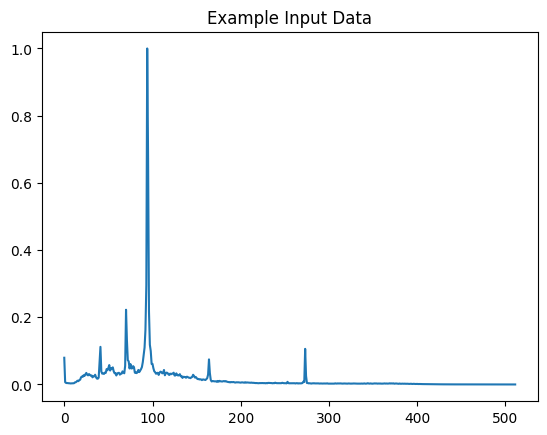

In [13]:
# Random State So it is reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

# Graph after scaling
print(f'Example Input Data: {X_train[0]}')
plt.figure()
plt.title("Example Input Data")
plt.plot(X_train[0])
plt.show()

In [15]:
train_coin_1 = 0
train_coin_2 = 0
train_coin_5 = 0
train_coin_20 = 0
train_coin_50 = 0
train_coin_100 = 0
train_coin_200 = 0

for i in range(y_train.shape[0]):
    if y_train[i] == 0:
        train_coin_1 += 1
    elif y_train[i] == 1:
        train_coin_2 += 1
    elif y_train[i] == 2:
        train_coin_5 += 1
    elif y_train[i] == 3:
        train_coin_20 += 1
    elif y_train[i] == 4:
        train_coin_50 += 1
    elif y_train[i] == 5:
        train_coin_100 += 1
    elif y_train[i] == 6:
        train_coin_200 += 1
        
print(f'coin 1: {train_coin_1}')
print(f'coin 2: {train_coin_2}')
print(f'coin 5: {train_coin_5}')
print(f'coin 20: {train_coin_20}')
print(f'coin 50: {train_coin_50}')
print(f'coin 100: {train_coin_100}')
print(f'coin 200: {train_coin_200}')

test_coin_1 = 0
test_coin_2 = 0
test_coin_5 = 0
test_coin_20 = 0
test_coin_50 = 0
test_coin_100 = 0
test_coin_200 = 0
for i in range(y_test.shape[0]):
    if y_test[i] == 0:
        test_coin_1 += 1
    elif y_test[i] == 1:
        test_coin_2 += 1
    elif y_test[i] == 2:
        test_coin_5 += 1
    elif y_test[i] == 3:
        test_coin_20 += 1
    elif y_test[i] == 4:
        test_coin_50 += 1
    elif y_test[i] == 5:
        test_coin_100 += 1
    elif y_test[i] == 6:
        test_coin_200 += 1
print(f'coin 1: {test_coin_1}')
print(f'coin 2: {test_coin_2}')
print(f'coin 5: {test_coin_5}')
print(f'coin 20: {test_coin_20}')
print(f'coin 50: {test_coin_50}')
print(f'coin 100: {test_coin_100}')
print(f'coin 200: {test_coin_200}')

coin 1: 118
coin 2: 138
coin 5: 104
coin 20: 112
coin 50: 100
coin 100: 146
coin 200: 157
coin 1: 33
coin 2: 32
coin 5: 26
coin 20: 25
coin 50: 30
coin 100: 34
coin 200: 39


In [16]:
# Creates TrainCoinDataSet
class TrainCoinDataSet(Dataset):

    def __init__(self, X_train, y_train):
        # Data Loading
        self.x = torch.from_numpy(X_train.astype(np.float32))
        self.y = torch.from_numpy(y_train).type(torch.LongTensor)
        self.n_samples = y_train.shape[0] # n_samples
        print(self.n_samples)

    def __getitem__(self, index):
        # Allows indexing
        return self.x[index], self.y[index]

    def __len__(self):
        # Allows calling length
        return self.n_samples
    
class TestCoinDataSet(Dataset):

    def __init__(self, X_test, y_test):
        # Data Loading
        self.x = torch.from_numpy(X_test.astype(np.float32))
        self.y = torch.from_numpy(y_test).type(torch.LongTensor)
        self.n_samples = y_test.shape[0] # n_samples
        print(self.n_samples)

    def __getitem__(self, index):
        # Allows indexing
        return self.x[index], self.y[index]

    def __len__(self):
        # Allows calling length
        return self.n_samples

In [17]:
# Creates Dataset
train_data = TrainCoinDataSet(X_train, y_train)
test_data = TestCoinDataSet(X_test, y_test)

875
219


In [19]:
# Defines Train and Test Datasets sizes
#train_size = int(0.8 * len(dataset))  # 80% of the data will be used for training
#test_size = len(dataset) - train_size  # Remaining 20% will be used for test

# Split dataset into training set and test set
#train_data, test_data = random_split(dataset, [train_size, test_size])

# Creates Dataloaders for train and test datasets
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False)

examples = iter(train_loader)
samples, labels = next(examples)


In [20]:
print(f'Input shape: {samples.shape} , Labels shape: {labels.shape}')
print(f"Input range after standardization: Min = {samples[0].min()}, Max = {samples[0].max()}")
print(samples[0])
print(labels[0])
print(f'Input dtype: {samples[0,0].dtype}')
print(f'Label dtype: {labels[0].dtype}')
print(f'Labels: {labels}')

Input shape: torch.Size([8, 512]) , Labels shape: torch.Size([8])
Input range after standardization: Min = 0.0, Max = 1.0
tensor([0.1424, 0.0963, 0.0801, 0.0615, 0.0472, 0.0389, 0.0342, 0.0262, 0.0159,
        0.0274, 0.0297, 0.0305, 0.0246, 0.0174, 0.0292, 0.0367, 0.0371, 0.0372,
        0.0356, 0.0366, 0.0440, 0.0370, 0.0328, 0.0358, 0.0416, 0.0536, 0.0611,
        0.0703, 0.0615, 0.0552, 0.0516, 0.0574, 0.0504, 0.0440, 0.0507, 0.0628,
        0.0685, 0.0547, 0.0678, 0.0639, 0.0374, 0.0462, 0.0466, 0.0415, 0.0441,
        0.0381, 0.0401, 0.0439, 0.0388, 0.0384, 0.0353, 0.0368, 0.0404, 0.0419,
        0.0453, 0.2806, 0.7056, 0.1379, 0.1085, 0.1090, 0.1181, 0.1135, 0.0952,
        0.1171, 0.0951, 0.1117, 0.1072, 0.0762, 0.0930, 0.0780, 0.1086, 0.0973,
        0.0892, 0.0945, 0.0734, 0.0576, 0.0512, 0.0545, 0.0521, 0.0425, 0.0559,
        0.0714, 0.0585, 0.0605, 0.0575, 0.0683, 0.0619, 0.0555, 0.0579, 0.0794,
        0.0893, 0.0983, 0.0887, 0.1176, 0.1281, 0.3002, 0.7716, 1.0000, 0.2022

In [21]:
# Create Model
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(RNN, self).__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, dropout=0.5)
        self.fc = nn.Linear(hidden_size, num_classes)   
        self.dropout = nn.Dropout(p=0.5)

    def forward(self,x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out,_ = self.rnn(x, h0)

        #Dropout on output
        out= self.dropout(out)
        
        out = out[:, -1, :]
        out= self.fc(out)
        return out

       

In [22]:
model = RNN(input_size, hidden_size, num_layers, num_classes).to(device)

#Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

KeyboardInterrupt: 

In [106]:
print(model)

RNN(
  (rnn): RNN(128, 128, num_layers=2, batch_first=True, dropout=0.5)
  (fc): Linear(in_features=128, out_features=7, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [107]:
# Training loop
history = {'train_loss': [], 'val_loss': [], 'train_acc':[], 'val_acc': []}
all_preds = []
all_labels = []

train_loss_steps = []
train_acc_steps = []
running_loss_train_steps = 0.0
n_correct_train_steps = 0
n_samples_train_steps = 0

plot_steps, print_steps = 20,1

running_loss_train = 0.0
n_correct_train = 0
n_samples_train = 0

running_loss_val = 0.0
n_correct_val = 0
n_samples_val = 0

for epoch in range(num_epochs):
    
    model.train()
    running_loss_train = 0.0
    n_correct_train = 0
    n_samples_train = 0

    # Training loop
    for i, (inputs, labels) in enumerate(train_loader):
        
        inputs = inputs.reshape(-1, sequence_length, input_size).to(device)
        labels = labels.to(device)
        
        # Forward
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # For Epoch Graph
        running_loss_train += loss.item()
        _, predictions = torch.max(outputs, 1)
        n_correct_train += (predictions == labels).sum().item()
        n_samples_train += labels.shape[0]

        # For Steps Graph
        running_loss_train_steps += loss.item()
        _, predictions = torch.max(outputs, 1)
        n_correct_train_steps += (predictions == labels).sum().item()
        n_samples_train_steps += labels.shape[0]
        
        if (i+1) % print_steps == 0:
            print(f'epoch {epoch+1} / {num_epochs}, step {i+1}/{len(train_loader)}, loss = {loss.item():.4f}')

        if (i+1) % plot_steps == 0:
            train_loss_steps.append(running_loss_train_steps / len(train_loader))
            train_acc_steps.append(100 * n_correct_train_steps / n_samples_train_steps)
            running_loss_train_steps = 0.0
            n_correct_train_steps = 0
            n_samples_train_steps = 0


    history['train_loss'].append(running_loss_train / len(train_loader))
    history['train_acc'].append(100 * n_correct_train / n_samples_train)

    # Test loop
    running_loss_val = 0.0
    n_correct_val = 0
    n_samples_val = 0

    model.eval()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            
            inputs = inputs.reshape(-1, sequence_length, input_size).to(device)
            labels = labels.to(device)
            
            # Forward
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Accumulate loss
            running_loss_val += loss.item()
            _, predictions = torch.max(outputs, 1)
            n_correct_val += (predictions == labels).sum().item()
            n_samples_val += labels.shape[0]

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            if (i+1) % print_steps == 0:
                print(f'epoch {epoch+1} / {num_epochs}, step {i+1}/{len(test_loader)}, loss = {loss.item():.4f}')

        history['val_loss'].append(running_loss_val / len(test_loader))
        history['val_acc'].append(100 * n_correct_val / n_samples_val)

epoch 1 / 50, step 1/110, loss = 1.9524
epoch 1 / 50, step 2/110, loss = 1.9533
epoch 1 / 50, step 3/110, loss = 1.9992
epoch 1 / 50, step 4/110, loss = 1.9750
epoch 1 / 50, step 5/110, loss = 1.9342
epoch 1 / 50, step 6/110, loss = 1.9561
epoch 1 / 50, step 7/110, loss = 1.9125
epoch 1 / 50, step 8/110, loss = 1.9892
epoch 1 / 50, step 9/110, loss = 1.9527
epoch 1 / 50, step 10/110, loss = 1.9499
epoch 1 / 50, step 11/110, loss = 1.9230
epoch 1 / 50, step 12/110, loss = 1.9177
epoch 1 / 50, step 13/110, loss = 1.9451
epoch 1 / 50, step 14/110, loss = 1.9356
epoch 1 / 50, step 15/110, loss = 1.9255
epoch 1 / 50, step 16/110, loss = 1.9096
epoch 1 / 50, step 17/110, loss = 1.9122
epoch 1 / 50, step 18/110, loss = 1.9662
epoch 1 / 50, step 19/110, loss = 1.9817
epoch 1 / 50, step 20/110, loss = 1.9127
epoch 1 / 50, step 21/110, loss = 1.8994
epoch 1 / 50, step 22/110, loss = 2.0119
epoch 1 / 50, step 23/110, loss = 1.9209
epoch 1 / 50, step 24/110, loss = 1.9390
epoch 1 / 50, step 25/110

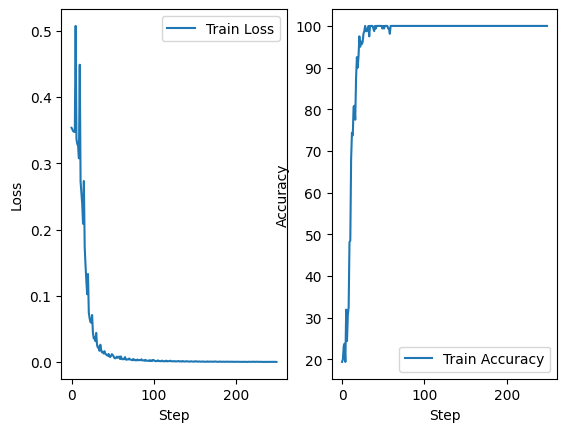

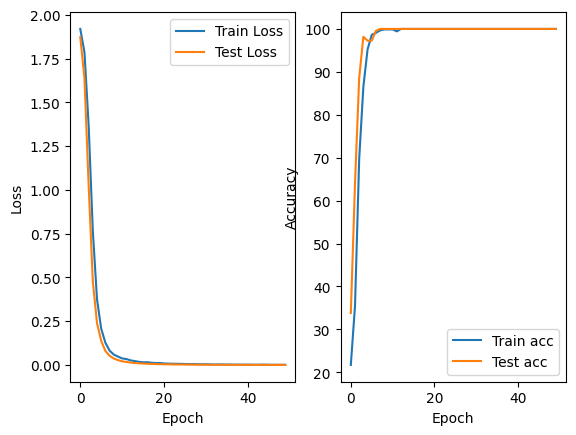

In [108]:
fig , ax = plt.subplots(1,2,sharex=True)

ax [0].plot(train_loss_steps, label='Train Loss')
ax [0].set_xlabel('Step')
ax [0].set_ylabel('Loss')
ax [0].legend()

ax [1].plot(train_acc_steps, label='Train Accuracy')
ax [1].set_xlabel('Step')
ax [1].set_ylabel('Accuracy')
ax [1].legend()

plt.savefig(results_dir + '/StepGraph.png')
plt.show() 

fig , ax = plt.subplots(1,2,sharex=True)

ax [0].plot(history['train_loss'], label='Train Loss')
ax [0].plot(history['val_loss'], label='Test Loss')
ax [0].set_xlabel('Epoch')
ax [0].set_ylabel('Loss')
ax [0].legend()

ax [1].plot(history['train_acc'], label='Train acc')
ax [1].plot(history['val_acc'], label='Test acc')
ax [1].set_xlabel('Epoch')
ax [1].set_ylabel('Accuracy')
ax [1].legend()

plt.savefig(results_dir + '/EpochGraph.png')
plt.show() 

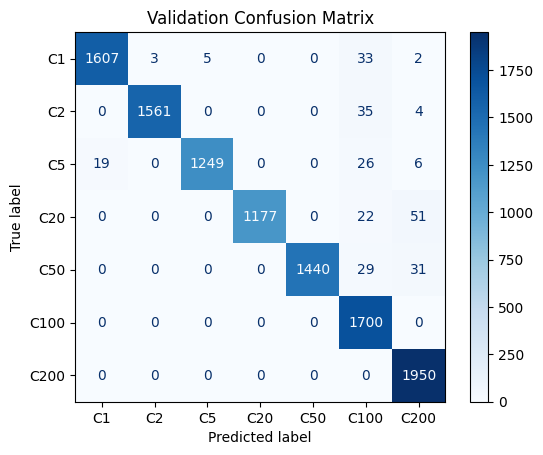

In [109]:
"""
Plot a confusion matrix using true and predicted labels.

Parameters:
    all_labels: List of true labels.
    all_preds: List of predicted labels.
    class_names: List of class names for labeling the confusion matrix.
"""
class_names = ['C1','C2','C5','C20','C50','C100','C200']
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Validation Confusion Matrix")
disp.figure_.savefig(results_dir + 'Confusion_Matrix.png')
plt.show()


In [110]:
print(f"after {num_epochs} epochs the trainning accuracy is {history["train_acc"][-1]} and the test accuaracy is {history["val_acc"][-1]} ")

test_accuracy_max= max(history["val_acc"])
train_accuracy_max=max(history["train_acc"])

idx_max_test_accuracy=history["val_acc"].index(test_accuracy_max)

idx_max_train_accuracy=history["train_acc"].index(train_accuracy_max)

print(f" the maximum accuracy of the test was {max(history["val_acc"])} at the epoch {idx_max_test_accuracy}")

print(f" the maximum accuracy of the train was {max(history["train_acc"])} at the epoch {idx_max_train_accuracy}")

print(f"the accuracy of the training at the best validation accuracy {max(history["val_acc"])} is {history["train_acc"][idx_max_test_accuracy]}  ")

after 50 epochs the trainning accuracy is 100.0 and the test accuaracy is 100.0 
 the maximum accuracy of the test was 100.0 at the epoch 7
 the maximum accuracy of the train was 100.0 at the epoch 12
the accuracy of the training at the best validation accuracy 100.0 is 99.65714285714286  


In [112]:
# Copy the file and results
shutil.copyfile('./rnn_fourier.ipynb', './' + results_dir + 'rnn_copy.ipynb')
torch.save(model.state_dict(), results_dir + "model_weights.pth")